<a href="https://colab.research.google.com/github/Lucas-O-S/N1B1-Regressao/blob/main/N1_Grupo_6_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Etapa 1 - Configuração do ambiente e carregamento dos dados


Confiração do ambiente

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
urlDataset = "https://raw.githubusercontent.com/Lucas-O-S/N1B1-Regressao/refs/heads/main/train(in).csv"

Viridis é uma paleta de cores que vai usar nos graficos sem precisar ficar passando cor pra cada um deles display max column vai mostrar todas as colunas do dataframe quando utilizar print(df) sem reduzir o numero "..."

In [14]:
sns.set_palette("viridis")
pd.set_option('display.max_columns', None)

criando uma variavel com numero 42 para garantir reprodutibilidade e o random seed vai gerar numeros aleatorios de NumPhy para embaralhar as linhas anted de dividir treinamento e teste

In [15]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ler o arquivo

In [16]:
data = pd.read_csv(urlDataset)


O trabalho aplica técnicas de Aprendizado de Máquina (AM) supervisionado à tarefa de regressão, com o objetivo de prever o preço de venda atual (current price) de veículos usados a partir de um conjunto de atributos técnicos e comerciais do carro.

# Etapa 2 - Análise exploratoria dos dados (EDA)

Pegar o numero de itens e numero de colunas, já o data info é um resume estrutural de cada coluna, verificar quantos valores não nulos tem, o tipo do dado.

In [17]:
print(f"Formato do dataset: {data.shape[0]} linhas x {data.shape[1]} colunas")
data.info()

Formato do dataset: 1000 linhas x 12 colunas
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   v.id           1000 non-null   int64  
 1   on road old    1000 non-null   int64  
 2   on road now    1000 non-null   int64  
 3   years          1000 non-null   int64  
 4   km             1000 non-null   int64  
 5   rating         1000 non-null   int64  
 6   condition      1000 non-null   int64  
 7   economy        1000 non-null   int64  
 8   top speed      1000 non-null   int64  
 9   hp             1000 non-null   int64  
 10  torque         1000 non-null   int64  
 11  current price  1000 non-null   float64
dtypes: float64(1), int64(11)
memory usage: 93.9 KB


data.describe() mostra estatisticas resumidas de cada coluna numérica do DataFrame

In [18]:
data.describe()

,v.id,on road old,on road now,years,km,rating,condition,economy,top speed,hp,torque,current price
count,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.00000
mean,500.500000,601648.286000,799131.3970,4.561000,100274.430000,2.988000,5.592000,11.625000,166.89300,84.54600,103.423000,308520.24250
std,288.819436,58407.246204,57028.9502,1.719079,29150.463233,1.402791,2.824449,2.230549,19.28838,20.51694,21.058716,126073.25915
min,1.000000,500265.000000,700018.0000,2.000000,50324.000000,1.000000,1.000000,8.000000,135.00000,50.00000,68.000000,28226.50000
25%,250.750000,548860.500000,750997.7500,3.000000,74367.500000,2.000000,3.000000,10.000000,150.00000,67.00000,85.000000,206871.75000
50%,500.500000,601568.000000,798168.0000,5.000000,100139.500000,3.000000,6.000000,12.000000,166.00000,84.00000,104.000000,306717.75000
75%,750.250000,652267.250000,847563.2500,6.000000,125048.000000,4.000000,8.000000,13.000000,184.00000,102.00000,121.000000,414260.87500
max,1000.000000,699859.000000,899797.0000,7.000000,149902.000000,5.000000,10.000000,15.000000,200.00000,120.00000,140.000000,584267.50000


Todos os atributos são numéricos (inteiros) — por isso a etapa de pré-processamento se concentrou em escalonamento (padronização) e não em codificação categórica.

Verificar se existem colunas com dado vazio se tiver mostra as colunas com problema, se não tiver vai aparecer nenhum valor encontrado e data.duplicated mostra se a linha é uma copia exata da anterior

linhas duplicadas é verificado com data.isnull().sum() e data.duplicated().sum()

In [19]:
missing = data.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Nenhum valor ausente encontrado.")

print(f"Linhas duplicadas: {data.duplicated().sum()}")

Nenhum valor ausente encontrado.
Linhas duplicadas: 0


O conjunto de dados utilizado (referido no enunciado como veiculos.csv, correspondente ao dataset “Second Hand Cars Data Set”) contém 1.000 observações e 12 colunas, sem valores ausentes e sem linhas duplicadas.

Gerar um histograma, o drop retira a coluna ou linha, neste caso, o v.id e devolve sem ela. já o frontsize e hist  quer pegar todas as colunas restante e desenha um histograma de cada um deles. O bins divide em intervalos de 30 faixas e conta quantas linhas caem em cada uma. Quanto mais bins mais detalhes, e menos tem uma vizão mais grosseira e suave. O figsizedefine o tamanho em polegadas largura e altura. Plt.suptitle adiciona o titulo geral e o plt.tight_layout não deixa as infos de sobrepoem e o show mostra as figuras

Após a remoção do identificador v.id (que não carrega informação preditiva, apenas um índice sequencial), restam 10 atributos numéricos utilizados como entrada dos modelos:

In [20]:
data_sem_id = data.drop(columns=['v.id'])

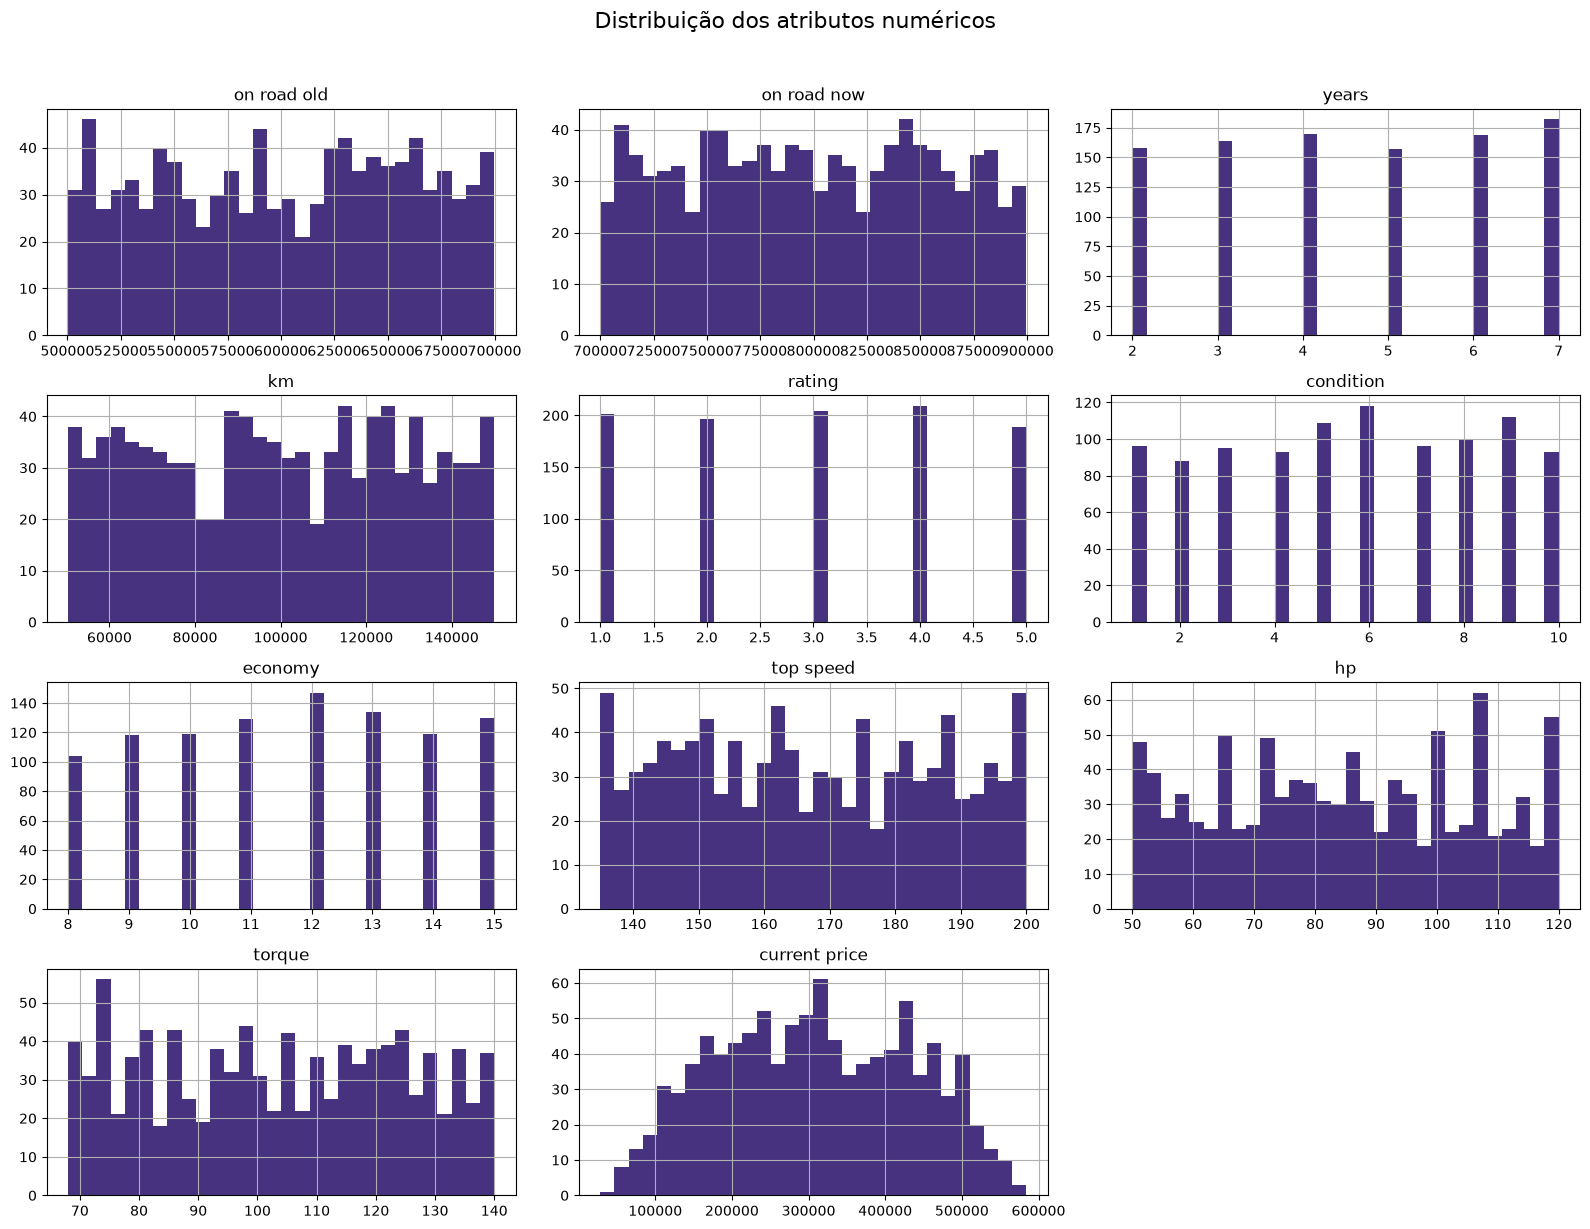

In [21]:
data_sem_id.hist(bins=30, figsize=(16, 12))
plt.suptitle("Distribuição dos atributos numéricos", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Distribuição razoavelmente uniforme ou levemente assimétrica, sem concentrações anômalas; já rating, years e condition assumem poucos valores discretos, o que explica seu aspecto “em barras espaçadas

BOXPLOT para identificar outliers. De novo retirar o id e o preço agora. plt.subplots cria figura dividida. axes indica é 2D e figsize o tamanho da figura inteira. flatten achata tudo em uma lista simples com 10 eixos. Mostra o 1 quartil 25%, ao 3 quartil 75%

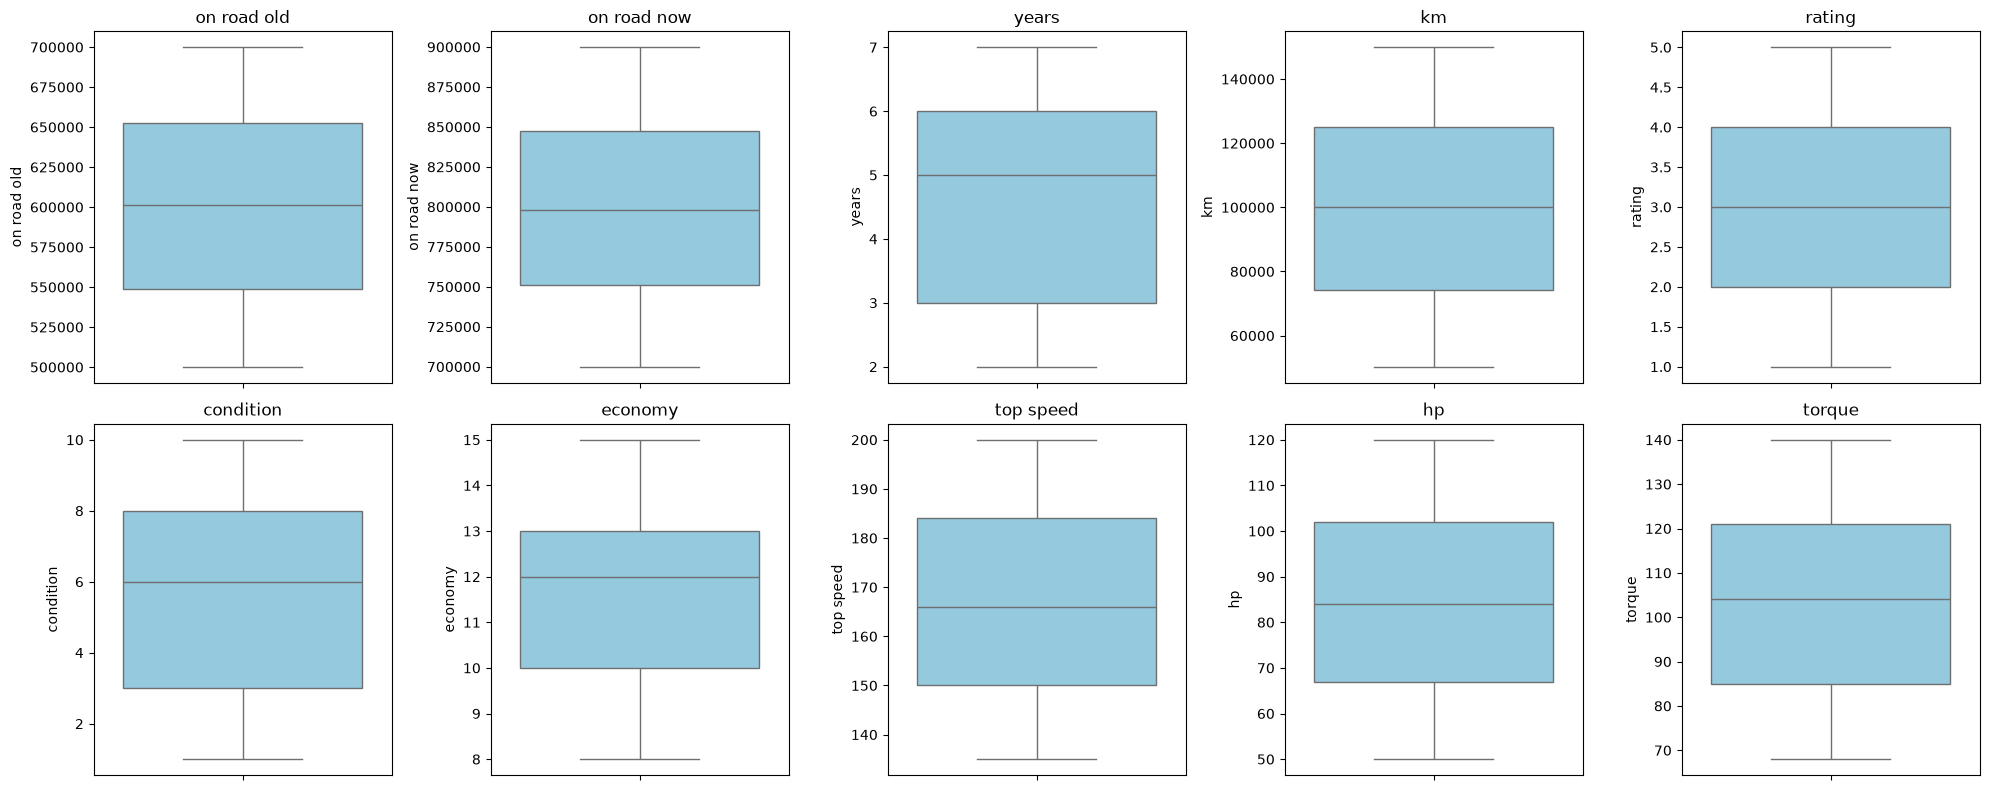

In [22]:
num_cols = data_sem_id.drop(columns=['current price']).columns
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=data[col], ax=ax, color='skyblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

km, on read ole e now e top speed tem maior variação. Já years, rating e condition por terem poucos valores possiveis não tem muita variação(sem outliers)

Os boxplots por atributo (excluindo v.id e a variável alvo) não evidenciam outliers relevantes: km, on road old/now e top speed são os atributos com maior amplitude de variação, enquanto years, rating e condition, por assumirem poucos valores possíveis, apresentam baixa dispersão e nenhum ponto fora dos limites do bigode (whisker)

Matriz de correlação com o alvo  o corr() calcula o coeficiente de correlação de Pearson, matriz quadrada de linhas e colunas com os mesmos nomes e vai de -1 a +1. Escolhemos a preço para mostrar as correlações com ele. Annot mostra numero de cada celula fmt é as casas decimais center força que o fique como branco

current price    1.000000
on road now      0.282793
on road old      0.233035
condition        0.110108
rating           0.035038
hp               0.030238
torque          -0.002290
years           -0.011854
top speed       -0.027993
economy         -0.034711
km              -0.935924
Name: current price, dtype: float64


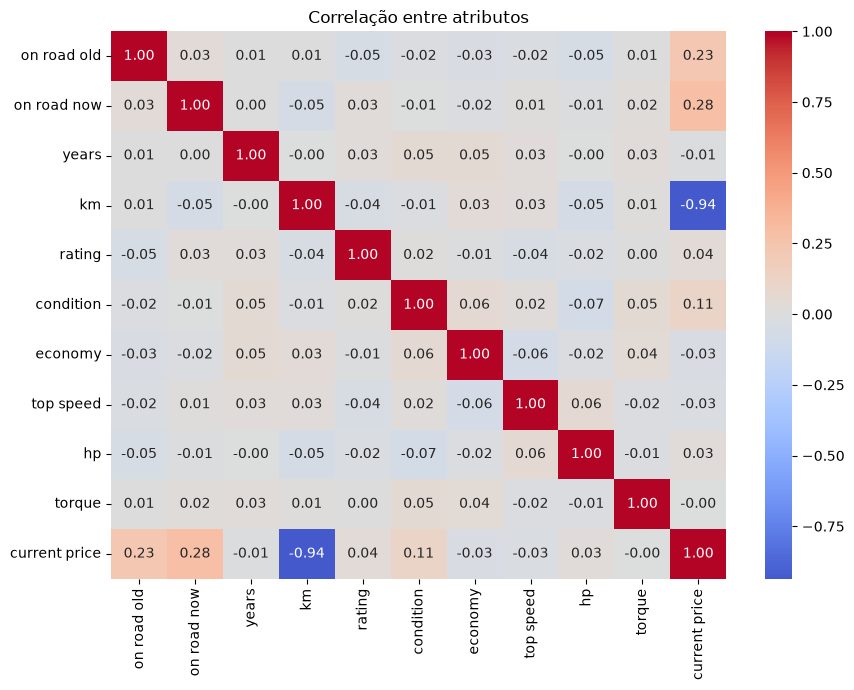

In [24]:
corr_matrix = data_sem_id.corr()
print(corr_matrix['current price'].sort_values(ascending=False))

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação entre atributos")
plt.tight_layout()
plt.show()

 km tem correlação negativa e forte com current prize - quanto mais rodado, menor o preço e on the road now e old tem correção positiva com o price.

 A matriz de correlação de Pearson entre os atributos e o current price revela um padrão dominante: a quilometragem (km) tem correlação negativa muito forte com o preço (−0,94) — quanto mais rodado o veículo, menor o preço de revenda. Os preços de tabela on road now (0,28) e on road old (0,23) têm correlação positiva moderada, e condition (0,11) tem correlação positiva fraca. As demais variáveis (years, rating, economy, top speed, hp, torque) apresentam correlação praticamente nula com o alvo.

Gráfico de dispersão entre cada atributo previsor e o alvo (current price), complementando os números da matriz de correlação com uma visão gráfica da relação entre as variáveis.

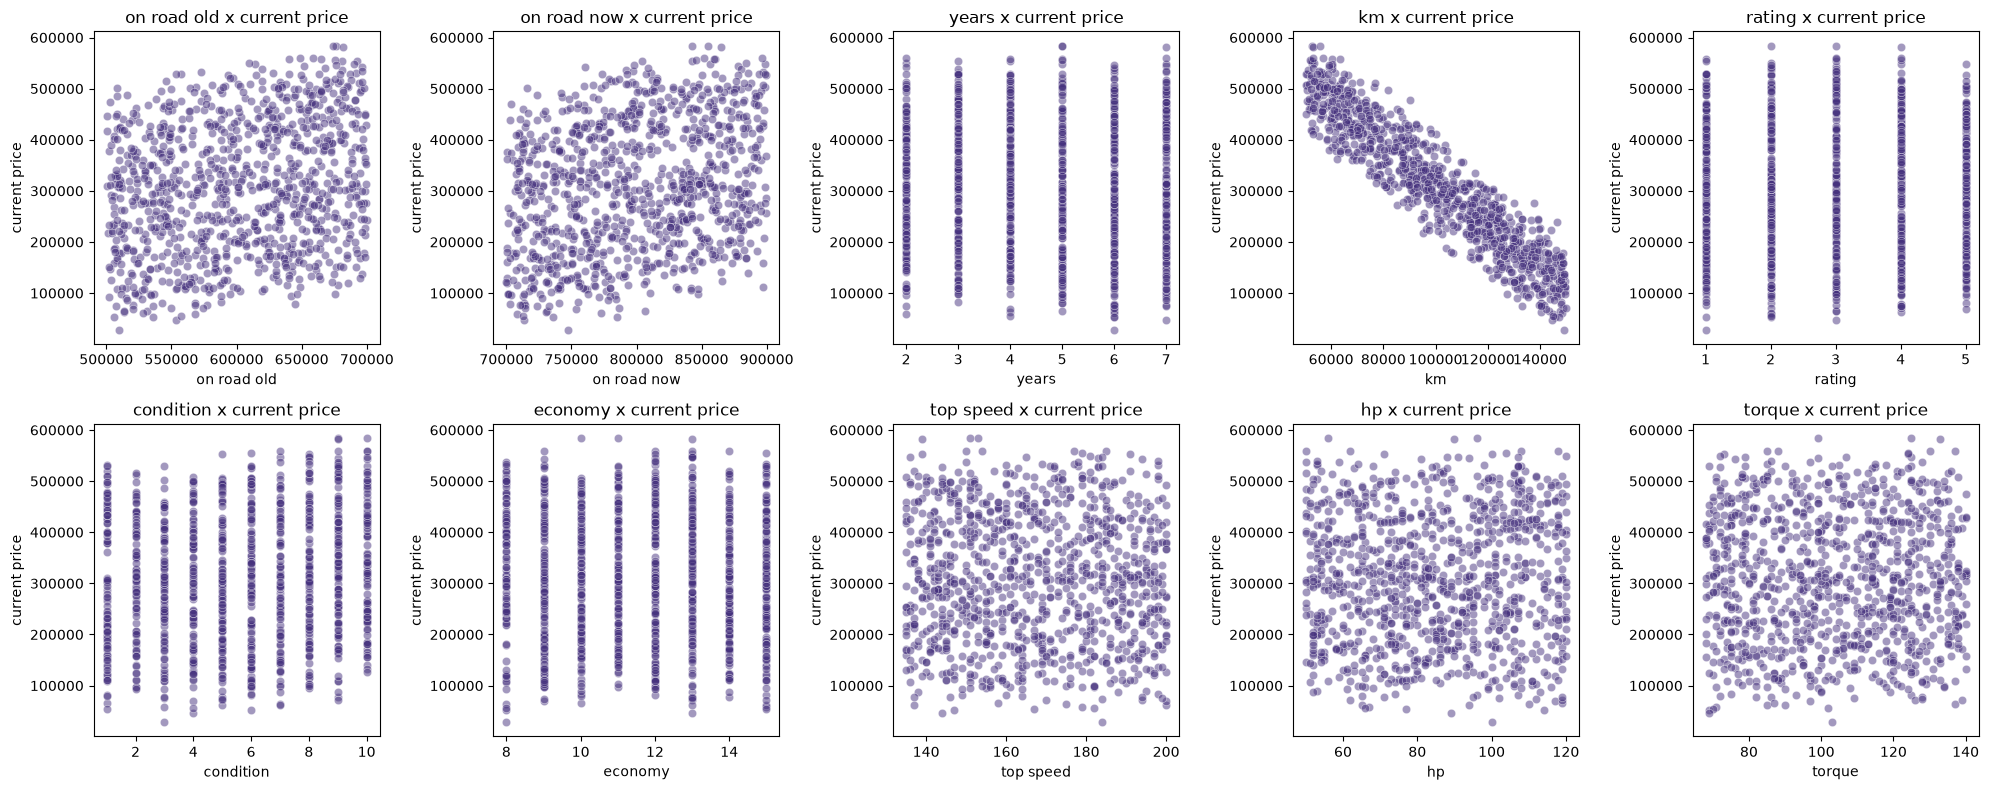

In [ ]:
num_cols = data_sem_id.drop(columns=['current price']).columns

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, col in zip(axes.flatten(), num_cols):
    
    sns.scatterplot(x=data_sem_id[col], y=data_sem_id['current price'], ax=ax, alpha=0.5)
    
    ax.set_title(f"{col} x current price")
    
plt.tight_layout()
plt.show()

## Etapa 3 - Separação entre treino e test - estratificação


O conjunto de dados foi embaralhado e dividido em 80% para treino e 20% para teste, utilizando train_test_split do scikit-learn com random_state = 42 para garantir reprodutibilidade. Isso resultou em 800 linhas de treino e 200 linhas de teste. As colunas v.id (identificador) e current price (alvo) foram removidas das matrizes de atributos (X_train / X_test) e a coluna current price foi isolada como vetor-alvo (y_train / y_test).

In [25]:
#embaralha e divide o dataset
# sklearn é quem divide
from sklearn.model_selection import train_test_split

# separa 20% para teste e guarda
#a cada 42 dados é separado a amostra teste
train_set, test_set = train_test_split(data, test_size=0.2, random_state=RANDOM_STATE)

#devolve o set de treino e o set de teste
print(f"Treino: {len(train_set)} linhas | Teste: {len(test_set)} linhas")

#elimina coluna de preço atual e o id do treinamento
X_train = train_set.drop(columns=['v.id', 'current price'])

#adiciona a coluna de preço atual para a copia do treinamento
y_train = train_set['current price'].copy()

#...do teste
X_test = test_set.drop(columns=['v.id', 'current price'])

#...do teste
y_test = test_set['current price'].copy()

Treino: 800 linhas | Teste: 200 linhas


Antes do treinamento, foram testados três novos atributos derivados, aplicados apenas sobre uma cópia do conjunto de treino: depreciação (on road old − on road now), km por ano (km / years) e hp por torque (hp / torque).

## Etapa 4 - Análise exploratória aprofundada - APENAS NO TESTE

X_train_extra precisa ser uma cópia do X_train e não o oficial.<br/>


In [26]:
X_train_extra = X_train.copy()

# desvalorização em relação ao preço de tabela na fábrica (quanto o carro já perdeu de valor)
X_train_extra['depreciacao'] = X_train_extra['on road old'] - X_train_extra['on road now']

# km rodados por ano de uso — separa "carro velho pouco usado" de "carro novo muito rodado"
X_train_extra['km_por_ano'] = X_train_extra['km'] / X_train_extra['years']

# cavalos de potência por torque, como proxy de perfil do motor
X_train_extra['hp_por_torque'] = X_train_extra['hp'] / X_train_extra['torque']

#cria conluna current price, ais=1 coloca as colunas lado a lado
corr_check = pd.concat([X_train_extra, y_train], axis=1)

#verifica se todas as colunas são realmente numericas
#depois filtra só a coluna current price, e a ordena crescente?
print(corr_check.corr(numeric_only=True)['current price'].sort_values(ascending=False))

current price    1.000000
on road now      0.273694
on road old      0.234771
condition        0.111200
hp               0.061127
rating           0.047479
hp_por_torque    0.042801
torque           0.017220
years           -0.008066
depreciacao     -0.026120
top speed       -0.029942
economy         -0.039360
km_por_ano      -0.466993
km              -0.933827
Name: current price, dtype: float64


 Nenhum deles superou os atributos originais em correlação com o alvo — km_por_ano chegou a −0,47, bem abaixo do −0,93 de km isolado — de modo que a decisão foi manter apenas os atributos originais, sem a adição desses derivados no pipeline final.

Nenhum dos novos atributos superou os atributos originais, então é melhor manter eles

## Etapa 5, 6, 7 e 8- Limpeza e tratamento dos dados nulos, engenharia de atributos, codificação de variáveis categorica e codificação de variaveis categoricas

Como todos os atributos são numéricos, a única transformação necessária foi colocar as variáveis na mesma escala, evitando que atributos com valores absolutos maiores (como on road now, na casa das centenas de milhares) dominassem artificialmente atributos de escala menor (como years ou rating). Foi utilizado o StandardScaler do scikit-learn, que padroniza cada coluna pela fórmula (x − média) / desvio-padrão.

In [27]:
# Importa a classe que faz a padronização z-scale
from sklearn.preprocessing import StandardScaler

#Cria uma instância ainda "vazia" — sem saber média/desvio-padrão de nada ainda
scaler = StandardScaler()

#fit calcula o desvio de cada coluna segundo o z-scaler e transform aplica a formula de padronização para todas as colunas (x-médio)/desvio padrão.
X_train_scaled = scaler.fit_transform(X_train_extra)

## Etapa 8 e 9 - Escalonamento de atributos e pipeline completo de pre processamento
Empacotar tudo em um Pipeline scikit-learn para deixar o processo reprodutivel e reaplicavel para o conjunto teste

In [28]:
#Cria uma classe que traz o BaseEstimador(dá todos os métodos que o sklearn tem como get e set) e TransformerMixin(método do fit_transform)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

#Herdar dessas duas classes é o que permite colocar AtributosDerivados() dentro de um Pipeline, lado a lado com StandardScaler e outros transformadores prontos
class AtributosDerivados(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
      #Devolve ele mesmo sem alteração
        return self

    def transform(self, X): #cria lógica com as formulas utilizadas anteriormente
        X = X.copy() #evitar que os dados originais e o X pode ser o treino ou teste
        X['depreciacao'] = X['on road old'] - X['on road now']
        X['km_por_ano'] = X['km'] / X['years']
        X['hp_por_torque'] = X['hp'] / X['torque']
        return X #devolve ele com as 3 colunas novas

full_pipeline = Pipeline([ #encadeia as transformações
    ('attribs_adder', AtributosDerivados()), #cria as colunas derivadas primeiro
    ('std_scaler', StandardScaler()), #padroniza tudo
])
#Isso é importante porque quando fizermos a amostra de teste só precisaremos utilizar a pipeline
X_train_prepared = full_pipeline.fit_transform(X_train)
print(X_train_prepared.shape)

(800, 13)


Todo o pré-processamento foi encapsulado em um Pipeline do scikit-learn, reunindo a criação dos atributos derivados testados e o StandardScaler, garantindo que exatamente as mesmas transformações ajustadas no treino sejam aplicadas ao conjunto de teste (fit apenas no treino, transform em treino e teste), evitando vazamento de dados (data leakage).

## Etapa 10, 11, 12 e 13 - Treinamento de modelos, avaliação com validação cruzada, ajuste de hiperparametros e importancia dos parametros

Treina três modelos diferentes de regressão nos mesmos dados preparados e compara o desempenho deles usando validação cruzada — é a etapa que efetivamente responde "qual desses algoritmos funciona melhor para prever o preço atual"

Foram treinados e comparados três modelos de regressão, todos do scikit-learn, avaliados por validação cruzada com 10 folds sobre o conjunto de treino, usando o erro quadrático médio (MSE) convertido em RMSE como métrica:

Regressão Linear (LinearRegression) — ajusta uma reta/hiperplano minimizando o erro quadrático.

Árvore de Decisão (DecisionTreeRegressor) — particiona os dados em regras if/else, capturando relações não lineares, mas sujeita a overfitting.

Random Forest (RandomForestRegressor, 100 árvores) — treina múltiplas árvores de decisão em subamostras diferentes e tira a média das previsões, reduzindo a variância em relação a uma única árvore.

[Regressão Linear] RMSE médio: 8,675 | desvio-padrão: 543
[Árvore de Decisão] RMSE médio: 29,115 | desvio-padrão: 1,767
[Random Forest] RMSE médio: 18,763 | desvio-padrão: 1,377


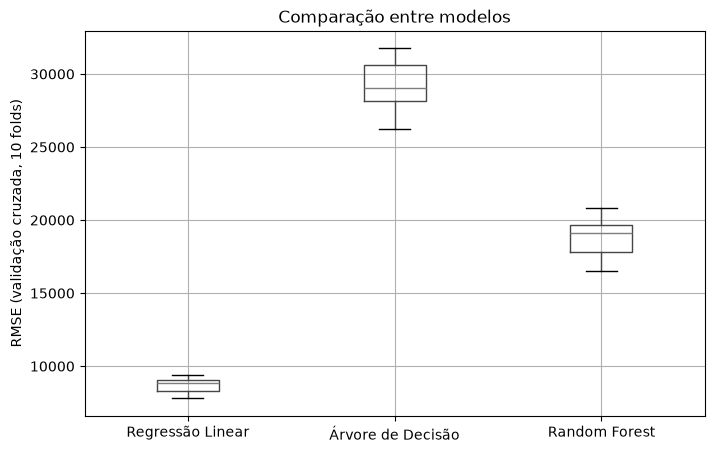

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score #função que faz a validação cruzada

modelos = {
    "Regressão Linear": LinearRegression(), #Ajusta uma reta tentando diminuir o erro quadrático
    "Árvore de Decisão": DecisionTreeRegressor(random_state=RANDOM_STATE), #sequecia de if/else que divide os dados,captura relações não lineares, porem pode ter overfitting
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), #treina 100 arvores de decisão diferentes e tira a média das previsões delas
    #n_jobs=-1 significa que usa todos os núcleos da CPU disponiveis para treinar mais rápido as arvores (em paralelo)
}

resultados = {}
for nome, modelo in modelos.items(): #percorre os itens, devolvendo os pares de nome e modelo
    #coração da validação cruzada
    scores = cross_val_score(modelo, X_train_prepared, y_train,
                              scoring='neg_mean_squared_error', cv=10) #o valor de cv significa o numero em que se divide as 800 amostras, no caso, 10 partes
                              #neg_mean_squared_error calcula em cada rodada mas em negativo
                              #a biblioteca sempre tenta maximizar a métrica de pontuação,o MSE é o erro equanto menor, melhor
                              # ele inverte o sinal para poder tratar "menos negativo" como "melhor".
    rmse_scores = np.sqrt(-scores) #o scores retorna 10 valores e o "-" inverte o valor voltando a ser positivo
    resultados[nome] = rmse_scores
    print(f"[{nome}] RMSE médio: {rmse_scores.mean():,.0f} | desvio-padrão: {rmse_scores.std():,.0f}")
                          # o quanto o valor varia de fold a fold indica estabiliadade
                          #:,.0f sem casas decimais

pd.DataFrame(resultados).boxplot(figsize=(8, 5)) #devolve um boxplot por coluna, uma por modelo
plt.ylabel("RMSE (validação cruzada, 10 folds)")
plt.title("Comparação entre modelos")
plt.show()

COMO FICARIA SE TIRARMOS AS OUTRAS VARIAVEIS DE TREINO E SÓ UTILIZASSEMOS A KM?

Após a comparação por validação cruzada, os três modelos foram treinados no conjunto de treino completo e avaliados no conjunto de teste (200 observações, nunca vistas durante o treinamento), usando duas métricas de avaliação para regressão:

RMSE (Root Mean Squared Error) — raiz do erro quadrático médio; penaliza mais fortemente erros grandes e está na mesma unidade da variável alvo (R$).

MAE (Mean Absolute Error) — erro absoluto médio; mede o erro médio “típico” em R$, sendo menos sensível a outliers do que o RMSE.

A Regressão Linear apresentou desempenho nitidamente superior aos demais modelos — erro médio de aproximadamente R$ 8.675, contra R$ 18.763 do Random Forest e R$ 29.115 da Árvore de Decisão. Esse resultado, embora incomum em comparações de regressão (modelos baseados em árvore costumam superar a regressão linear em relações não lineares), faz sentido neste dataset porque, como mostrado na Seção 2.3, a quilometragem (km) já explica sozinha grande parte da variação do preço de forma aproximadamente linear — cenário em que a Regressão Linear tem vantagem estrutural sobre modelos baseados em árvores.

Os resultados no conjunto de teste confirmam o ranking observado na validação cruzada: a Regressão Linear é o modelo com melhor desempenho, com erro típico de aproximadamente R$ 7.497 a R$ 8.948 sobre preços que variam de ~R$ 28 mil a ~R$ 584 mil — um erro relativo pequeno frente à faixa de preços do dataset.

## Etapa 14 - Avaliação final do conjunto teste

Na prática, quanto mais "colados" na linha vermelha os pontos ficarem, melhor o modelo. E como predito na etapa 13, a Regressa Linear é o melhor dos métodos.

A Análise Exploratória de Dados mostrou que a quilometragem rodada (km) é, isoladamente, o atributo mais informativo, com correlação de −0,94 com o preço, seguida pelos preços de tabela do veículo (on road now e on road old). Essa relação fortemente linear explica por que a Regressão Linear superou modelos mais flexíveis como Árvore de Decisão e Random Forest, tanto na validação cruzada quanto no conjunto de teste, atingindo RMSE de aproximadamente R$ 8.948 e MAE de aproximadamente R$ 7.497 — os menores erros entre os três modelos avaliados.

RMSE no teste: 8,948
MAE no teste : 7,497


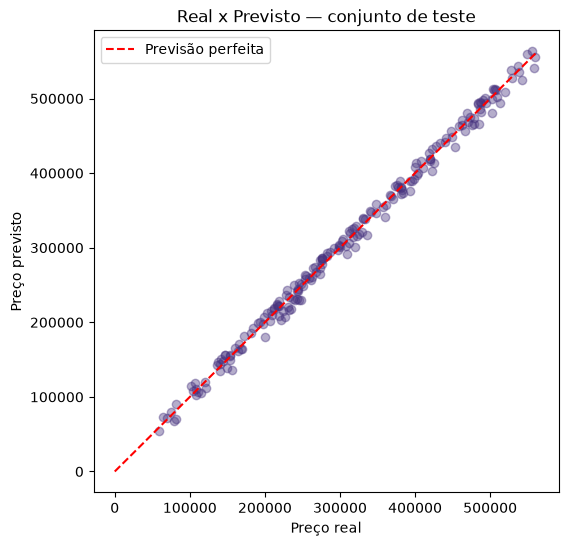

In [37]:
melhor_modelo = LinearRegression() #não tem aleatoriedade nem paralelismo por padrão
melhor_modelo.fit(X_train_prepared, y_train)

X_test_prepared = full_pipeline.transform(X_test)
preds = melhor_modelo.predict(X_test_prepared)

from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = mean_squared_error(y_test, preds) ** 0.5
mae = mean_absolute_error(y_test, preds)
print(f"RMSE no teste: {rmse:,.0f}")
print(f"MAE no teste : {mae:,.0f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.4) #cada ponto é um carro do teste: eixo X o preço real, eixo Y o preço previsto.
lims = [0, max(y_test.max(), preds.max())] #calcula o maior valor entre o maior preço real e a maior previsão, para desenhar uma linha de referência
plt.plot(lims, lims, 'r--', label='Previsão perfeita') #desenha a reta diagonal y = x (pontilhada, vermelha)
                                                        # se um ponto cai exatamente sobre essa linha, a previsão foi perfeita para aquele carro.
# rotulagem padrão do gráfico
plt.xlabel("Preço real")
plt.ylabel("Preço previsto")
plt.legend()
plt.title("Real x Previsto — conjunto de teste")
plt.show()

O gráfico de dispersão abaixo compara, para cada veículo do conjunto de teste, o preço real (eixo X) com o preço previsto pelo modelo (eixo Y). A linha tracejada vermelha representa a previsão perfeita (y = x): quanto mais próximos os pontos estiverem dessa linha, melhor o modelo.

Como um extra, também foi feito os outros dois métodos, como esperado os pontos estao mais longe da predição e a fórmula para utiliza-los é um pouco diferente.

Em ambos os casos os pontos se afastam mais da linha de previsão perfeita do que na Regressão Linear, especialmente para preços mais altos, o que é coerente com o RMSE/MAE maiores reportados na tabela acima.

RMSE no teste: 19,441
MAE no teste : 15,183


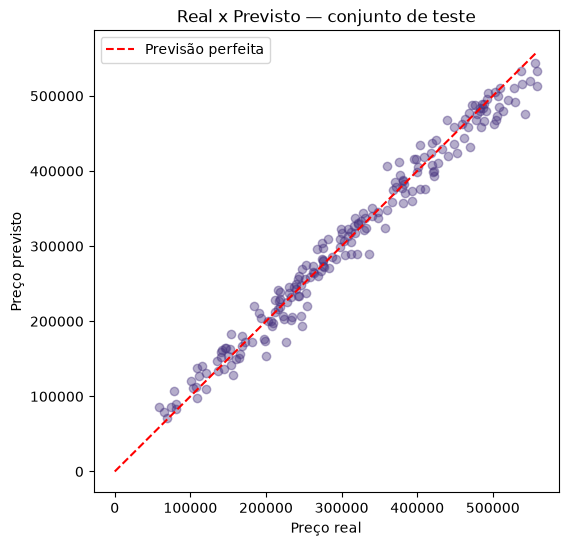

In [38]:
# Cria uma instância nova do modelo (com os mesmos hiperparâmetros usados na comparação anterior)
# precisa de n_estimators/random_state/n_jobs, pois tem tem aleatoriedade e paralelismo por padrão
segundo_melhor_modelo = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1) #*NAO É O MELHOR*, mas para ver que precisa
segundo_melhor_modelo.fit(X_train_prepared, y_train)

X_test_prepared = full_pipeline.transform(X_test)
preds = segundo_melhor_modelo.predict(X_test_prepared)

from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = mean_squared_error(y_test, preds) ** 0.5
mae = mean_absolute_error(y_test, preds)
print(f"RMSE no teste: {rmse:,.0f}")
print(f"MAE no teste : {mae:,.0f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.4)
lims = [0, max(y_test.max(), preds.max())]
plt.plot(lims, lims, 'r--', label='Previsão perfeita')
plt.xlabel("Preço real")
plt.ylabel("Preço previsto")
plt.legend()
plt.title("Real x Previsto — conjunto de teste")
plt.show()

RMSE no teste: 32,417
MAE no teste : 24,697


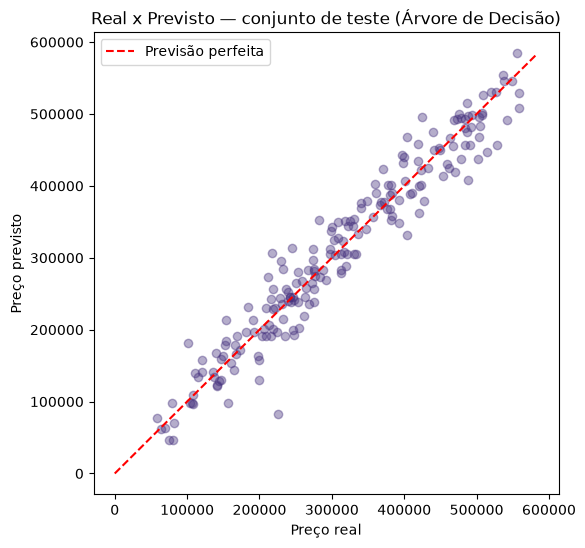

In [39]:
from sklearn.tree import DecisionTreeRegressor

terceiro_melhor_modelo = DecisionTreeRegressor(random_state=RANDOM_STATE)
terceiro_melhor_modelo.fit(X_train_prepared, y_train)

X_test_prepared = full_pipeline.transform(X_test)
preds = terceiro_melhor_modelo.predict(X_test_prepared)

from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = mean_squared_error(y_test, preds) ** 0.5
mae = mean_absolute_error(y_test, preds)
print(f"RMSE no teste: {rmse:,.0f}")
print(f"MAE no teste : {mae:,.0f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.4)
lims = [0, max(y_test.max(), preds.max())]
plt.plot(lims, lims, 'r--', label='Previsão perfeita')
plt.xlabel("Preço real")
plt.ylabel("Preço previsto")
plt.legend()
plt.title("Real x Previsto — conjunto de teste (Árvore de Decisão)")
plt.show()

Conclui-se que, para este dataset, a Regressão Linear é o modelo recomendado, sendo ao mesmo tempo o mais simples, o mais interpretável e o de melhor desempenho preditivo.

#Etapa 15 - Teste considerando apenas KMs como variavel#

[Regressão Linear] RMSE médio (só km): 44,871 | desvio-padrão: 1,663
[Árvore de Decisão] RMSE médio (só km): 62,503 | desvio-padrão: 4,098
[Random Forest] RMSE médio (só km): 53,651 | desvio-padrão: 4,112


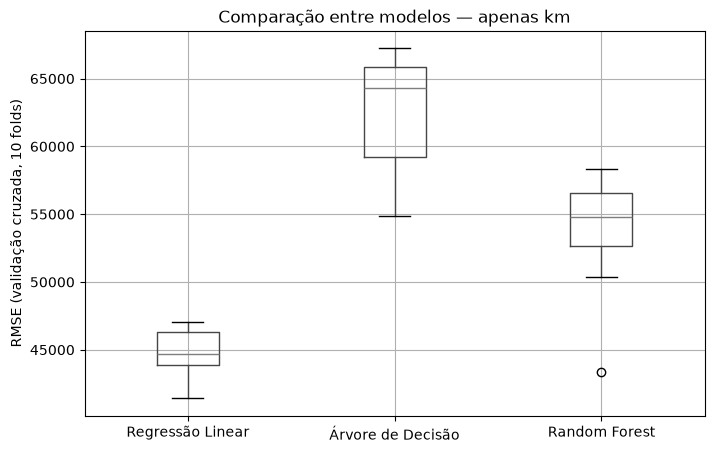

In [40]:
#refaz a divisão treino/teste mantendo só a coluna km como previsora
X_train_km = train_set[['km']]
X_test_km = test_set[['km']]

#escalona km isoladamente (mesmo princípio do StandardScaler usado no pipeline completo)
scaler_km = StandardScaler()
X_train_km_prepared = scaler_km.fit_transform(X_train_km)
X_test_km_prepared = scaler_km.transform(X_test_km)

#mesma validação cruzada de 10 folds, comparando os 3 modelos usando só km
resultados_km = {}
for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train_km_prepared, y_train,
                              scoring='neg_mean_squared_error', cv=10)
    rmse_scores = np.sqrt(-scores)
    resultados_km[nome] = rmse_scores
    print(f"[{nome}] RMSE médio (só km): {rmse_scores.mean():,.0f} | desvio-padrão: {rmse_scores.std():,.0f}")

pd.DataFrame(resultados_km).boxplot(figsize=(8, 5))
plt.ylabel("RMSE (validação cruzada, 10 folds)")
plt.title("Comparação entre modelos — apenas km")
plt.show()

RMSE no teste (só km): 43,022
MAE no teste (só km) : 35,083


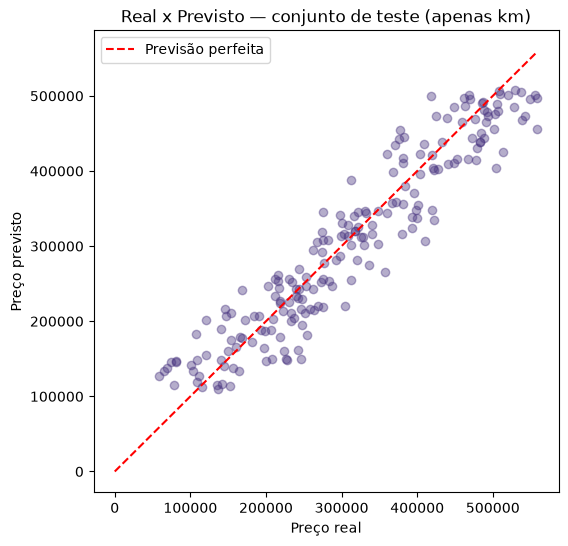

In [41]:
#treina o melhor modelo (Regressão Linear) só com km e avalia no teste
modelo_km = LinearRegression()
modelo_km.fit(X_train_km_prepared, y_train)
preds_km = modelo_km.predict(X_test_km_prepared)

rmse_km = mean_squared_error(y_test, preds_km) ** 0.5
mae_km = mean_absolute_error(y_test, preds_km)
print(f"RMSE no teste (só km): {rmse_km:,.0f}")
print(f"MAE no teste (só km) : {mae_km:,.0f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds_km, alpha=0.4)
lims = [0, max(y_test.max(), preds_km.max())]
plt.plot(lims, lims, 'r--', label='Previsão perfeita')
plt.xlabel("Preço real")
plt.ylabel("Preço previsto")
plt.legend()
plt.title("Real x Previsto — conjunto de teste (apenas km)")
plt.show()

Usando apenas km como variável previsora, a validação cruzada (10 folds) mostrou RMSE médio de 44.871 para a Regressão Linear, 62.503 para a Árvore de Decisão e 53.651 para o Random Forest — o mesmo ranking observado com todos os atributos, mas com erros muito maiores. No conjunto de teste, a Regressão Linear com apenas km obteve RMSE de 43.022 e MAE de 35.083, contra RMSE de 8.948 e MAE de 7.497 do modelo com todos os atributos (Etapa 14).

Isso mostra que, apesar de km ter isoladamente a correlação mais forte com o preço (−0,94), ela sozinha não é suficiente: os atributos on road now (0,28) e on road old (0,23) agregam informação complementar (o preço de tabela do veículo) que reduz o erro em cerca de 5 vezes. km captura a tendência geral de desvalorização pelo uso, mas não o patamar de preço de cada veículo — daí o gráfico real x previsto ficar bem mais disperso em torno da linha de previsão perfeita do que na versão com todos os atributos.